## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting? 
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** [To be provided]

**Date:** [To be provided]

(338, 4)
voltage      0
height       0
soil         0
mine_type    0
dtype: int64
mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64


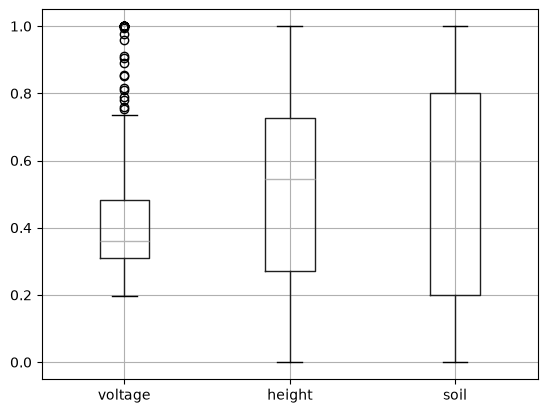

In [ ]:
# Your Phase 1 solution to the problem goes here.
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

#ask how much eda is needed, shoudl i plot too? 
df = pd.read_csv('land_mines.csv')
print(df.shape) # dimensions are 338 x 4, 338 observations
print(df.isna().sum()) #there's no missing data in any of the columns 
df[['voltage', 'height', 'soil']].describe().round(3)
df.groupby("mine_type")[["voltage", "height", "soil"]].mean().round(3)
print(df["mine_type"].value_counts().sort_index())


box = df.boxplot(column=['voltage', 'height', 'soil'])
plt.show()



In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

eval_X_raw = df[["voltage", "height", "soil"]]
eval_y = df["mine_type"]
(
    eval_X_train_raw,
    eval_X_valid_raw,
    eval_y_train,
    eval_y_valid,
) = train_test_split(
    eval_X_raw, eval_y, test_size=0.50, random_state=65
)

eval_scaler = MinMaxScaler()
eval_X_train_scaled = eval_scaler.fit_transform(eval_X_train_raw)
eval_X_valid_scaled = eval_scaler.transform(eval_X_valid_raw)


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
classification_model = KNeighborsClassifier(n_neighbors=3).fit(
    eval_X_train_scaled, eval_y_train
) # mine_X_train_scaled are the examples we want the model to learn from, while eval_y_train are the corresponding results 

print("Validation accuracy (k = 3):",
      round(classification_model.score(eval_X_valid_scaled, eval_y_valid), 3))

k_values = range(1,51)
validation_accuracies = []
for k in k_values: 
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(eval_X_train_scaled, eval_y_train)
    validation_accuracies.append(knn_k.score(eval_X_valid_scaled, eval_y_valid))

k_position = k_values[int(np.argmax(validation_accuracies))]
print(k_position) #most optimal k 
print(round(classification_model.score(eval_X_valid_scaled, eval_y_valid), 3))
)






Validation accuracy (k = 3): 0.402
2


## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [4]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]